In [1]:
# import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('winequality-red.csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [4]:
#count of quality feature
df['quality'].value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

<Axes: xlabel='quality', ylabel='count'>

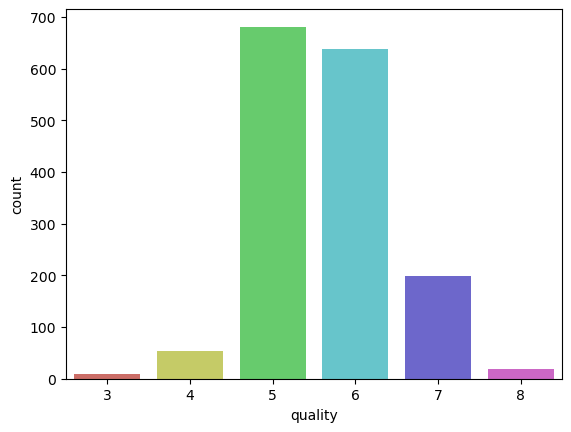

In [5]:
sns.countplot(x = df['quality'], palette= 'hls')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [7]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [8]:
# duplicates
df.duplicated().sum()

np.int64(240)

In [9]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

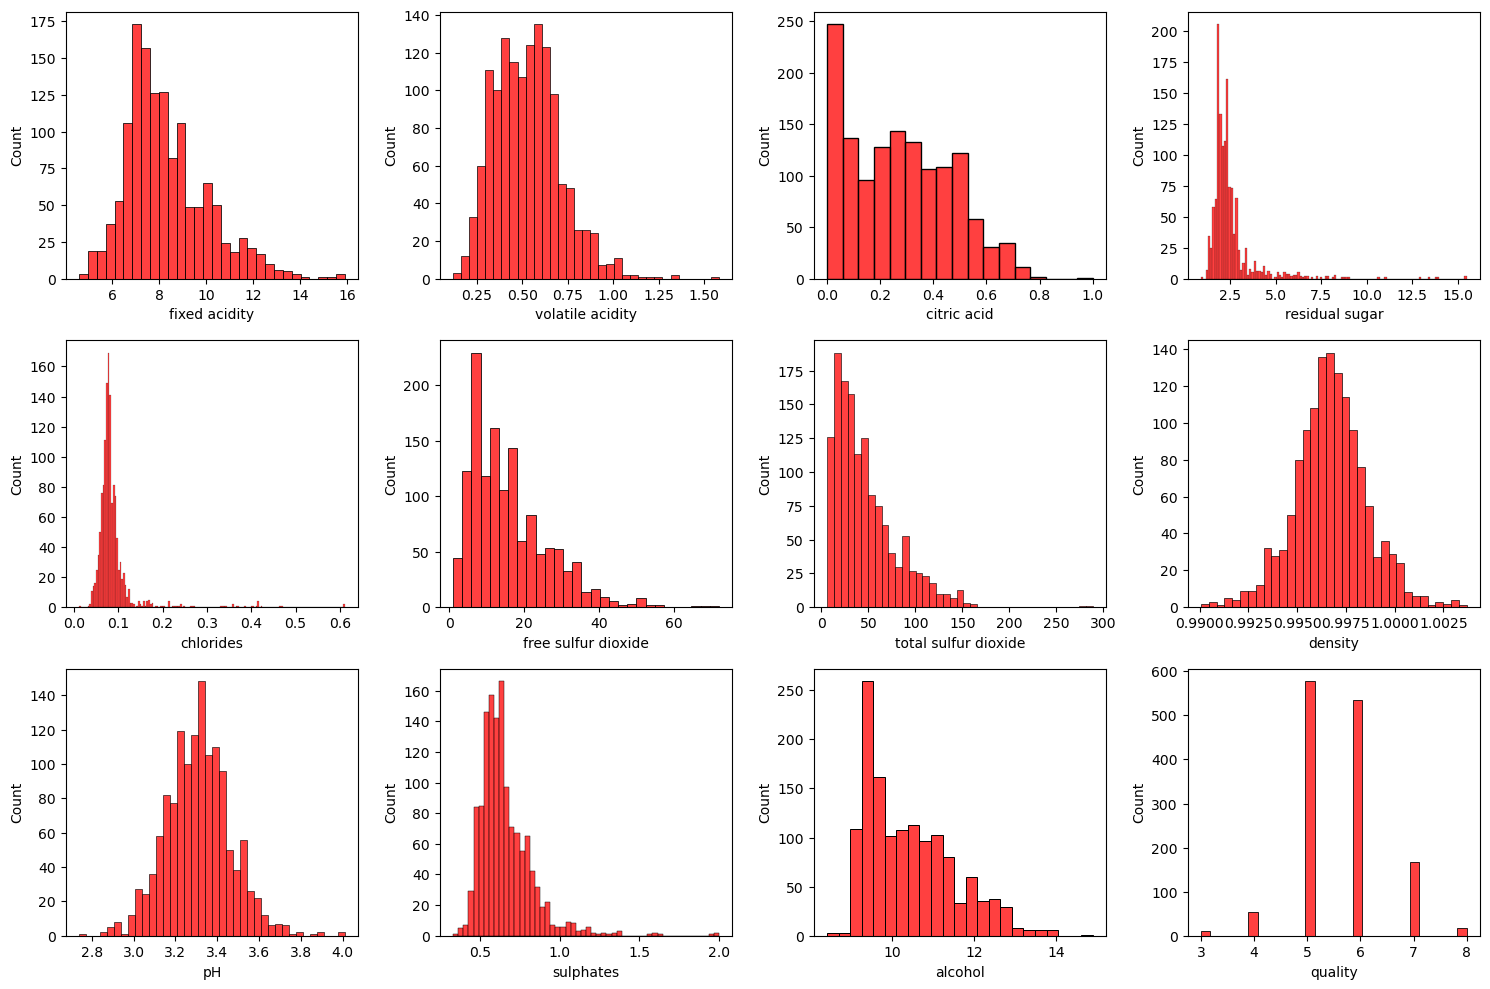

In [10]:
#plot the 3*4 subplot on the same figure
fig, axes = plt.subplots(nrows = 3, ncols = 4, figsize = (15,10))
k = 0
for i in range(3):
    for j in range(4):
            sns.histplot(df[df.columns[k]], ax = axes[i][j], color = 'red')
            k += 1
plt.tight_layout()
plt.show()

In [11]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [12]:
# apply log transform on features
#df["volatile acidity"]=np.log(df["volatile acidity"])
#df["citric acid"]=np.log(df["citric acid"])
df["residual sugar"]=np.log(df["residual sugar"])
df["chlorides"]=np.log(df["chlorides"])
df["free sulfur dioxide"]=np.log(df["free sulfur dioxide"])
df["total sulfur dioxide"]=np.log(df["total sulfur dioxide"])
df["sulphates"]=np.log(df["sulphates"])
#df["alcohol"]=np.log(df["alcohol"])



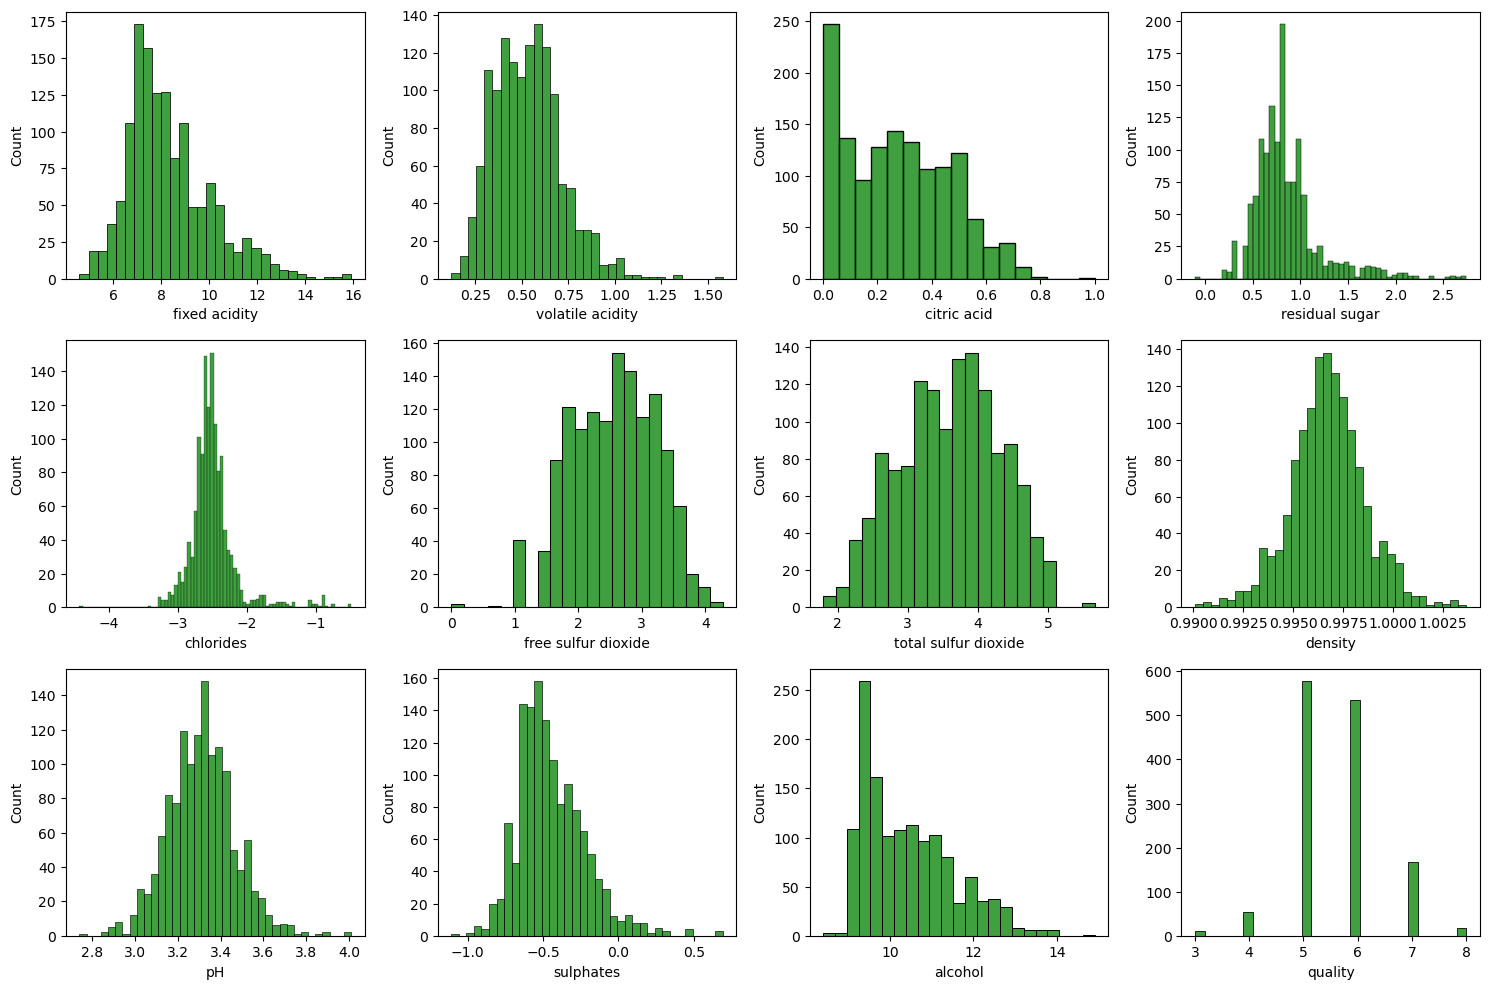

In [13]:
#plot the 3*4 subplot on the same figure
fig, axes = plt.subplots(nrows = 3, ncols = 4, figsize = (15,10))
k = 0
for i in range(3):
    for j in range(4):
            sns.histplot(df[df.columns[k]], ax = axes[i][j], color = 'green')
            k += 1
plt.tight_layout()
plt.show()

In [14]:
X = df.drop('quality',axis='columns')
y = df['quality']

In [15]:
X.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,0.641854,-2.577022,2.397895,3.526361,0.9978,3.51,-0.579818,9.4
1,7.8,0.88,0.00,0.955511,-2.322788,3.218876,4.204693,0.9968,3.20,-0.385662,9.8
2,7.8,0.76,0.04,0.832909,-2.385967,2.708050,3.988984,0.9970,3.26,-0.430783,9.8
3,11.2,0.28,0.56,0.641854,-2.590267,2.833213,4.094345,0.9980,3.16,-0.544727,9.8
5,7.4,0.66,0.00,0.587787,-2.590267,2.564949,3.688879,0.9978,3.51,-0.579818,9.4


In [16]:
X.isnull().sum()   

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
dtype: int64

In [17]:
y.value_counts()

quality
5    577
6    535
7    167
4     53
8     17
3     10
Name: count, dtype: int64

In [18]:
from imblearn.over_sampling import SMOTE
oversample = SMOTE(k_neighbors=4)
# transform the dataset
X, y = oversample.fit_resample(X.fillna(0), y)

In [19]:
y.value_counts()

quality
5    577
6    577
7    577
4    577
8    577
3    577
Name: count, dtype: int64

In [20]:
X.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,3462.000000,3462.000000,3462.000000,3462.000000,3462.000000,3462.000000,3462.000000,3462.000000,3462.000000,3462.000000,3462.000000
mean,8.282975,0.590326,0.260725,0.864796,-2.514163,2.368091,3.347442,0.996452,3.333896,-0.447688,10.759674
std,1.682355,0.254458,0.203708,0.347165,0.316514,0.660108,0.694531,0.001889,0.152538,0.219186,1.195775
min,4.600000,0.120000,0.000000,-0.105361,-4.422849,0.000000,1.791759,0.990070,2.740000,-1.108663,8.400000
25%,7.150915,0.390089,0.050000,0.641854,-2.673649,1.791759,2.733682,0.995225,3.230000,-0.612950,9.778362
50%,7.900000,0.547958,0.250000,0.788457,-2.551046,2.397895,3.318648,0.996480,3.323834,-0.467723,10.600000
75%,9.300000,0.739012,0.432979,0.993252,-2.419119,2.854315,3.868495,0.997623,3.435212,-0.289567,11.600000
max,15.900000,1.580000,1.000000,2.740840,-0.492658,4.276666,5.666427,1.003690,4.010000,0.693147,14.900000


In [21]:
# apply standard scalar
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X = scaler.transform(X)
X = pd.DataFrame(X)
X.head()

,0,1,2,3,4,5,6,7,8,9,10
0,-0.524920,0.431072,-1.280083,-0.642274,-0.198628,0.045156,0.257648,0.713779,1.154659,-0.602911,-1.137229
1,-0.287124,1.138559,-1.280083,0.261340,0.604721,1.289043,1.234466,0.184221,-0.877915,0.283022,-0.802670
2,-0.287124,0.666901,-1.083695,-0.091864,0.405083,0.515079,0.923839,0.290133,-0.484514,0.077138,-0.802670
3,1.734144,-1.219732,1.469353,-0.642274,-0.240481,0.704717,1.075561,0.819691,-1.140183,-0.442790,-0.802670
4,-0.524920,0.273852,-1.280083,-0.798035,-0.240481,0.298264,0.491680,0.713779,1.154659,-0.602911,-1.137229


In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [23]:
y_test.value_counts()

quality
5    162
3    150
7    145
6    143
8    140
4    126
Name: count, dtype: int64

In [24]:
# Apply LogRegression

from sklearn.linear_model import LogisticRegression
model_LogReg = LogisticRegression()
model_LogReg.fit(X_train,y_train)
LogReg_acc=round(model_LogReg.score(X_test, y_test)*100)
LogReg_acc

64

In [25]:
# apply decision tree model
from sklearn.tree import DecisionTreeClassifier
model_DT = DecisionTreeClassifier()
model_DT.fit(X_train,y_train)
DT_acc=round(model_DT.score(X_test, y_test)*100)
DT_acc

72

In [26]:
#svm
from sklearn.svm import SVC
model_SVM = SVC()
model_SVM.fit(X_train,y_train)
SVM_acc=round(model_SVM.score(X_test, y_test)*100)
SVM_acc

77

In [27]:
#apply random forest model
from sklearn.ensemble import RandomForestClassifier
model_RF = RandomForestClassifier()
model_RF.fit(X_train,y_train)
RF_acc=round(model_RF.score(X_test, y_test)*100)
RF_acc

83

In [28]:
Accuracy = [LogReg_acc, DT_acc, RF_acc, SVM_acc]
models = ['LogisticRegression', 'DecisionTreeClassifier' , 'RandomForestClassifier', 'Support Vector Machine']

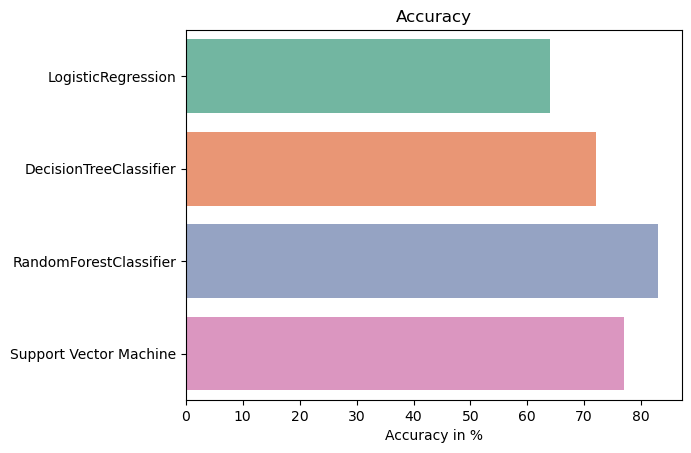

In [29]:
sns.barplot(x=Accuracy, y=models, palette="Set2")
plt.xlabel('Accuracy in %')
plt.title('Accuracy')
plt.show()

In [30]:
# get confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, model_RF.predict(X_test))
cm

array([[150,   0,   0,   0,   0,   0],
       [  0, 121,   5,   0,   0,   0],
       [  6,  11, 102,  38,   4,   1],
       [  1,   7,  36,  73,  20,   6],
       [  0,   0,   1,   9, 132,   3],
       [  0,   0,   0,   0,   0, 140]])

In [31]:
y_test.value_counts()

quality
5    162
3    150
7    145
6    143
8    140
4    126
Name: count, dtype: int64

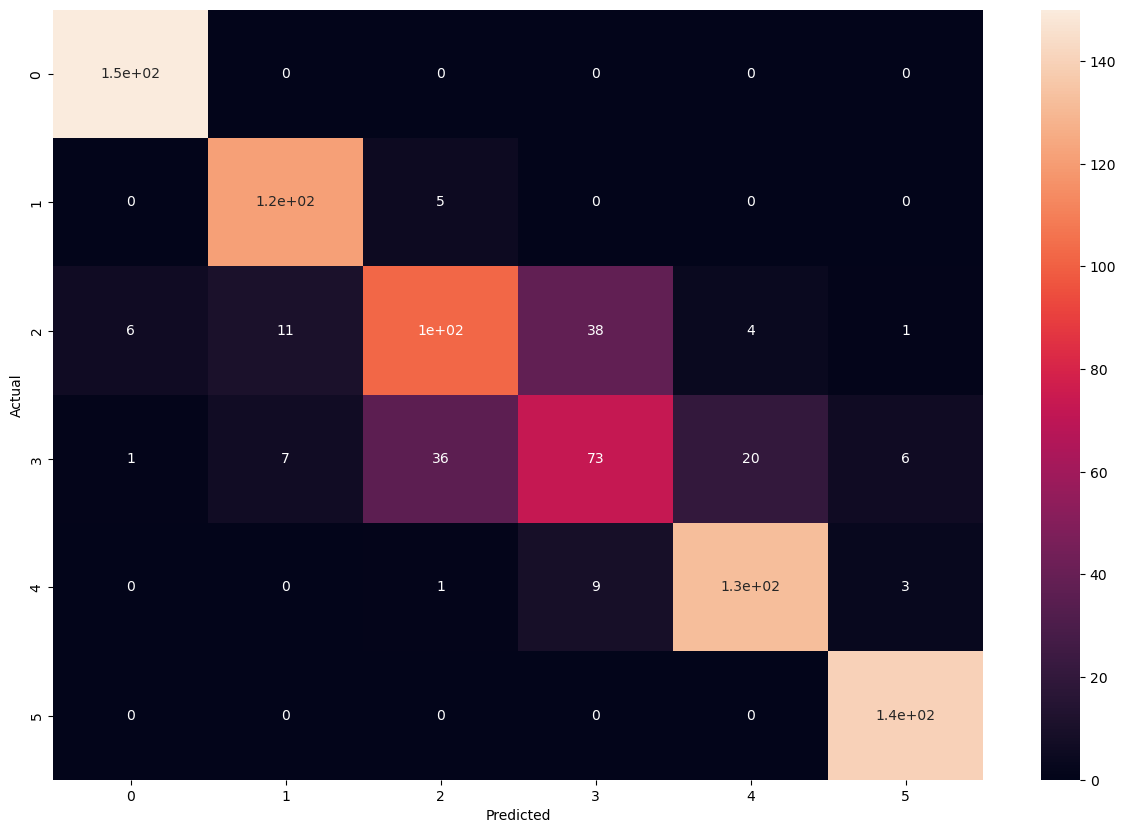

In [32]:
#heatmap for cm
import seaborn as sns
plt.figure(figsize = (15,10))
sns.heatmap(cm, annot = True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

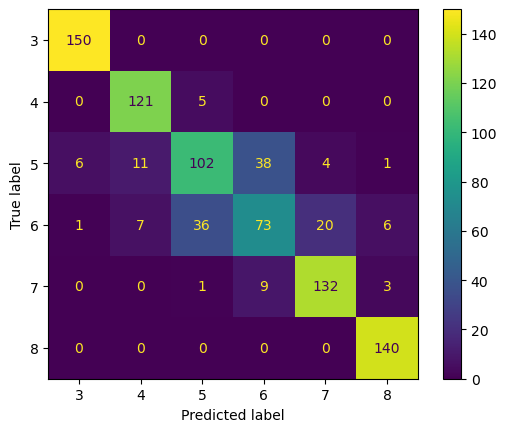

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay

cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=model_RF.classes_)
cm_display.plot()
plt.show()


In [34]:
# save Random forest model
import pickle
filename = 'finalized_RFmodel.sav'
pickle.dump(model_RF, open(filename, 'wb'))

In [35]:
#save scaler
import pickle
filename = 'scaler_model.sav'
pickle.dump(scaler, open(filename, 'wb'))

In [36]:
import numpy as np
import pickle

# Load saved model and scaler
with open("finalized_RFmodel.sav", "rb") as f:
    model = pickle.load(f)

with open("scaler_model.sav", "rb") as f:
    scaler = pickle.load(f)

# List of feature names in correct order
feature_names = [
    'fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
    'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
    'pH', 'sulphates', 'alcohol'
]

# Collect input values from user
print("Enter the following details for prediction:")

user_values = []
for feature in feature_names:
    val = float(input(f"Enter {feature}: "))
    user_values.append(val)

# Convert to array and reshape
input_data = np.array(user_values).reshape(1, -1)

# Scale using the fitted scaler
scaled_data = scaler.transform(input_data)

# Predict
prediction = model.predict(scaled_data)

print(f"\nPredicted Wine Quality: {prediction[0]}")


Enter the following details for prediction:


ValueError: could not convert string to float: ''